# 01 - Exploratory Data Analysis
**Goal:** Understand the data before touching any KPI or model.

Steps:
1. Load data, check shape/dtypes/nulls
2. Distribution of each numeric column
3. Efficiency_Status class balance (already know: 78/19/3 split)
4. Create Network Quality bands (Low/Medium/High) from latency + packet loss
5. Save a processed CSV with the new band column to data/processed/

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/Thales_Group_Manufacturing.csv')
df.head()

,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,01-01-2025,00:00:00,39,Idle,74.138,3.501,8.612,10.651,0.208,7.751,477.657,0.345,14.965,Low
1,01-01-2025,00:01:00,29,Active,84.265,3.356,2.269,29.112,2.228,4.989,398.175,0.770,7.678,Low
2,01-01-2025,00:02:00,15,Active,44.280,2.080,6.144,18.357,1.639,0.457,108.075,0.987,8.198,Low
3,01-01-2025,00:03:00,43,Active,40.569,0.298,4.068,29.154,1.161,4.583,329.579,0.983,2.741,Medium
4,01-01-2025,00:04:00,8,Idle,75.064,0.346,6.226,34.029,4.797,2.288,159.114,0.573,12.101,Low


## Data Quality Checks
Before any analysis, confirm the data is clean: correct shape, correct types, no missing values, no duplicates.

In [17]:
df.shape

(100000, 14)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           100000 non-null  str    
 1   Timestamp                      100000 non-null  str    
 2   Machine_ID                     100000 non-null  int64  
 3   Operation_Mode                 100000 non-null  str    
 4   Temperature_C                  100000 non-null  float64
 5   Vibration_Hz                   100000 non-null  float64
 6   Power_Consumption_kW           100000 non-null  float64
 7   Network_Latency_ms             100000 non-null  float64
 8   Packet_Loss_%                  100000 non-null  float64
 9   Quality_Control_Defect_Rate_%  100000 non-null  float64
 10  Production_Speed_units_per_hr  100000 non-null  float64
 11  Predictive_Maintenance_Score   100000 non-null  float64
 12  Error_Rate_%                   100000 non-

In [19]:
df.isnull().sum()

Date                             0
Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.describe()

,Machine_ID,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25.499330,60.041460,2.549959,5.745929,25.55562,2.493418,5.008806,275.916324,0.499384,7.504101
std,14.389439,17.323239,1.414127,2.451271,14.12076,1.443273,2.883666,130.096892,0.288814,4.335895
min,1.000000,30.000000,0.100000,1.500000,1.00000,0.000000,0.000000,50.000000,0.000000,0.000000
25%,13.000000,45.031500,1.323000,3.627000,13.35500,1.245000,2.521750,162.873750,0.248000,3.750000
50%,25.000000,60.033500,2.549000,5.755000,25.53600,2.488000,5.003500,276.649000,0.499000,7.504000
75%,38.000000,74.967250,3.776000,7.860000,37.79625,3.741000,7.506000,388.812500,0.749000,11.273000
max,50.000000,89.999000,5.000000,10.000000,50.00000,5.000000,10.000000,499.997000,1.000000,15.000000


## Outlier Detection and Distribution Shape
`describe()` gives ranges, but boxplots reveal outliers precisely — values statistically far from the bulk of the data, not just extremes. Histograms show whether each variable is normally distributed, skewed, or multi-modal.

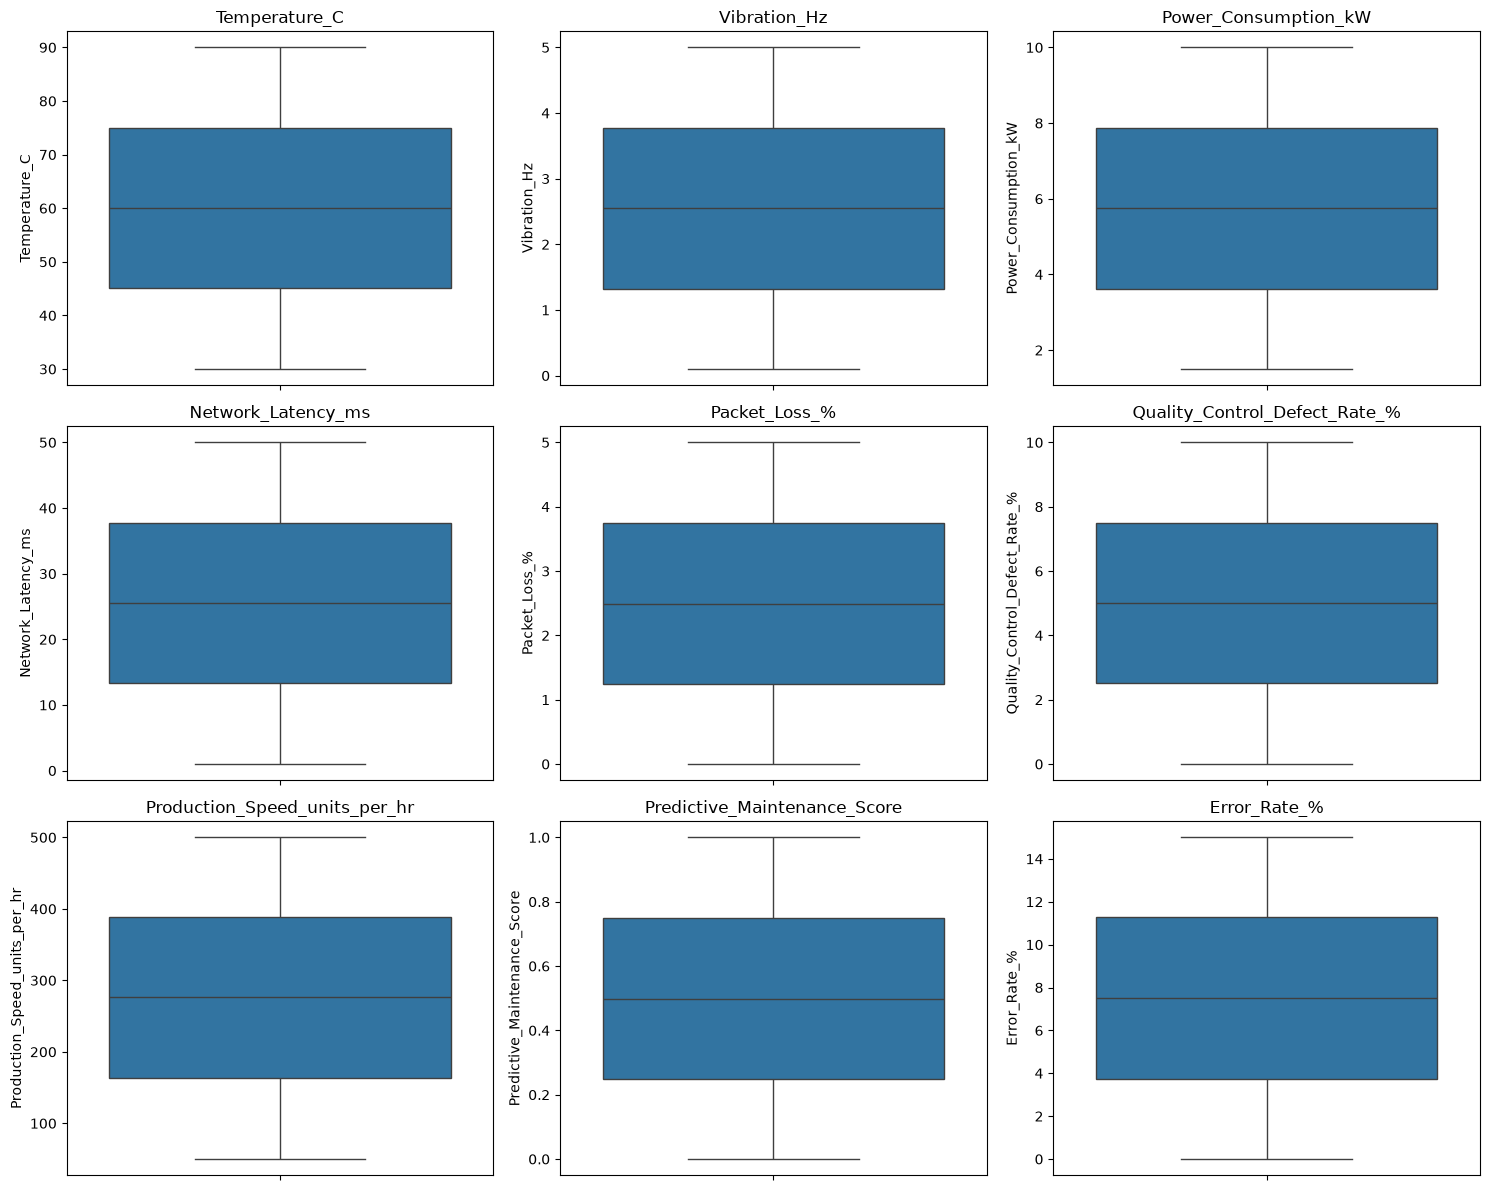

In [22]:
numeric_cols = ['Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
                 'Network_Latency_ms', 'Packet_Loss_%', 
                 'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
                 'Predictive_Maintenance_Score', 'Error_Rate_%']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [23]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

Temperature_C: 0 outliers (0.00%)
Vibration_Hz: 0 outliers (0.00%)
Power_Consumption_kW: 0 outliers (0.00%)
Network_Latency_ms: 0 outliers (0.00%)
Packet_Loss_%: 0 outliers (0.00%)
Quality_Control_Defect_Rate_%: 0 outliers (0.00%)
Production_Speed_units_per_hr: 0 outliers (0.00%)
Predictive_Maintenance_Score: 0 outliers (0.00%)
Error_Rate_%: 0 outliers (0.00%)


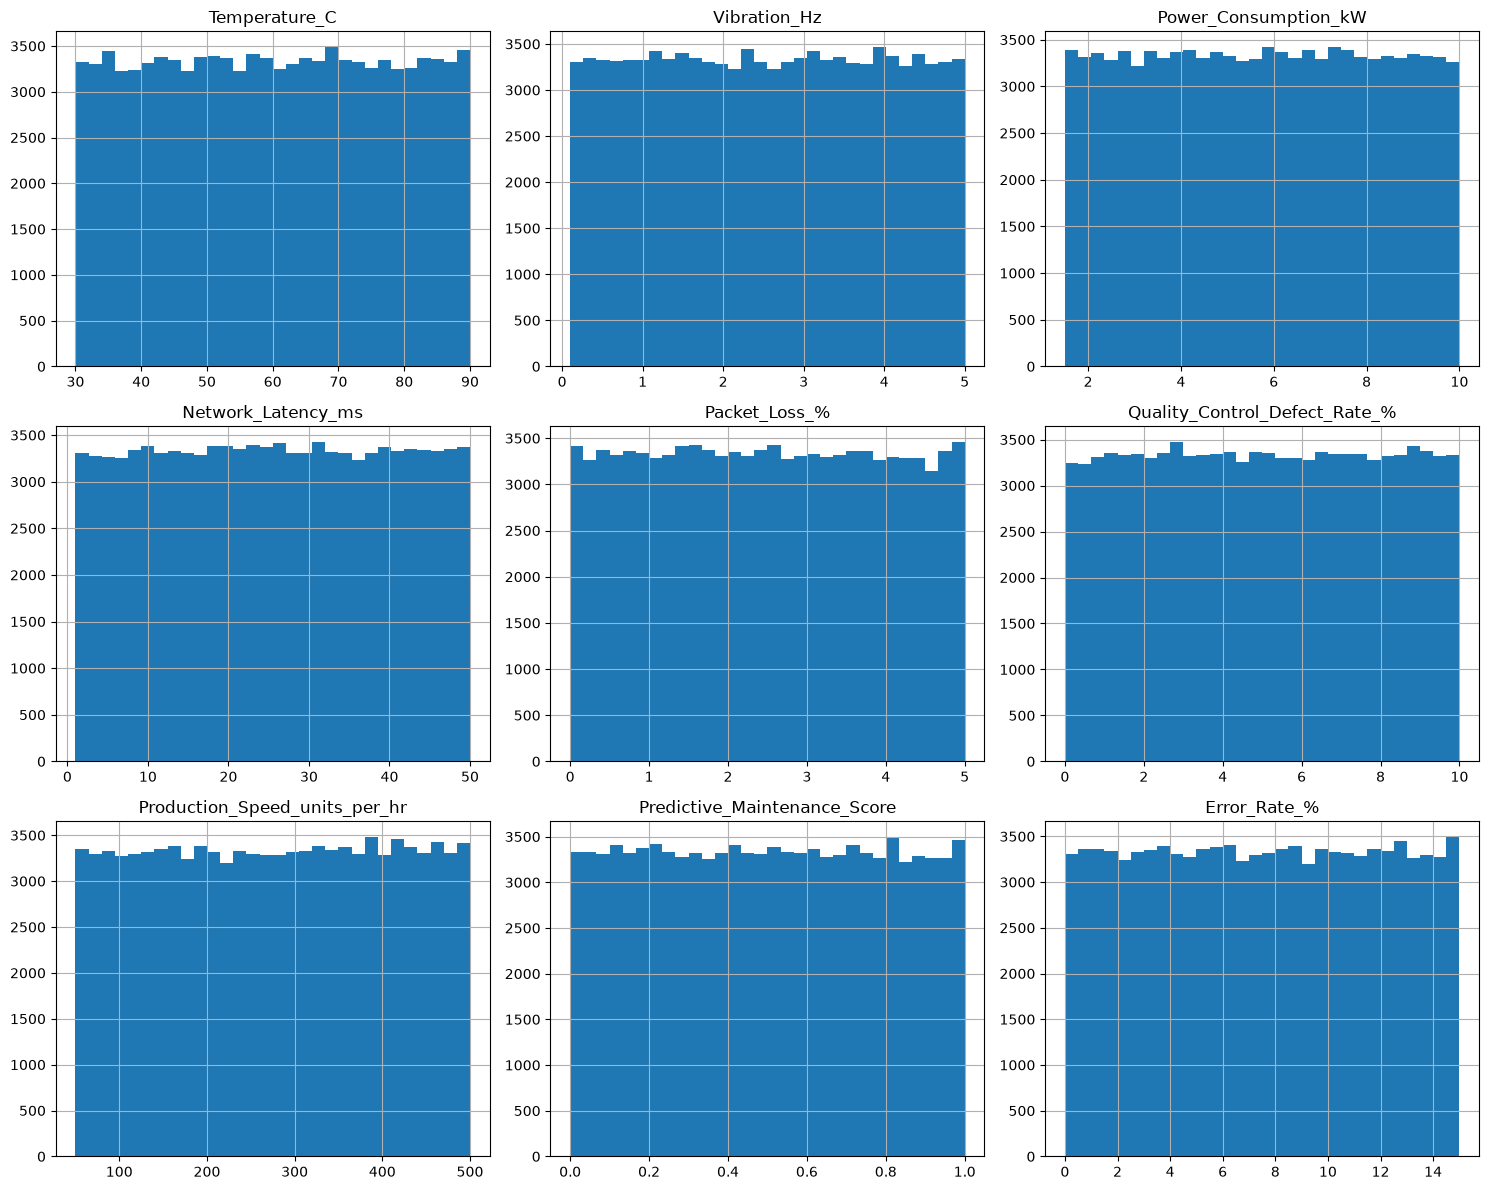

In [24]:
df[numeric_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

**Observation:** 0 outliers detected across all numeric columns via IQR method — suggests data may be synthetically generated with bounded/controlled distributions rather than real sensor logs, which typically show some natural extremes.

## Categorical Variable Distributions
Check the balance of Operation_Mode and, critically, the target variable Efficiency_Status.

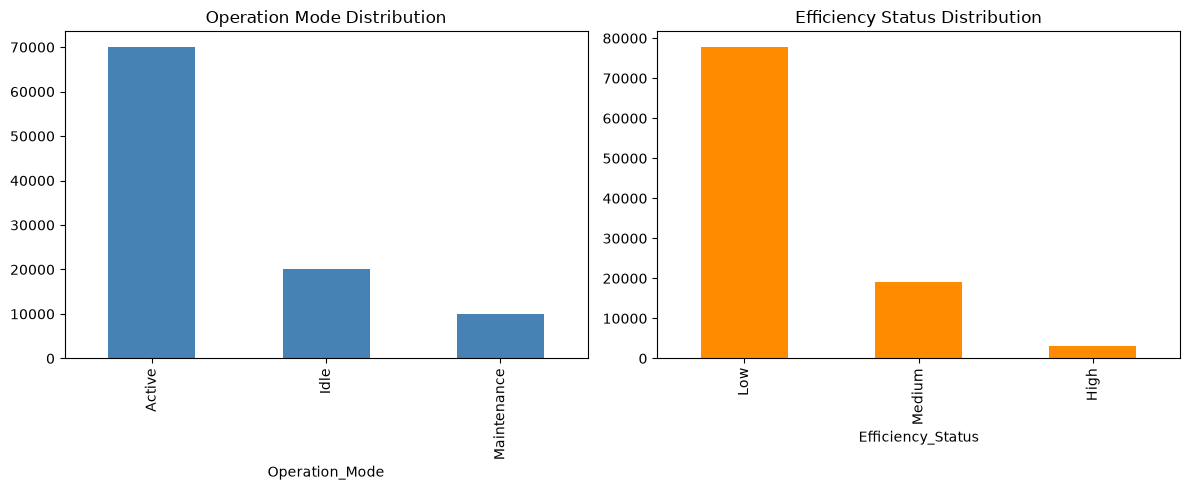

Efficiency_Status
Low       77.825
Medium    19.189
High       2.986
Name: proportion, dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Operation_Mode'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Operation Mode Distribution')

df['Efficiency_Status'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Efficiency Status Distribution')

plt.tight_layout()
plt.show()

print(df['Efficiency_Status'].value_counts(normalize=True) * 100)